### Setup and Imports

In [81]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

### Data Ingestion

In [78]:
# Rounding the dates to month end, the last 4 Teasury notes are off

df = pd.read_excel("../Data/treasury_quotes_2025-11-28.xlsx", sheet_name="selected quotes")
df['quote date'] = df['quote date'] + pd.offsets.MonthEnd(0)
df['maturity date'] = df['maturity date'] + pd.offsets.MonthEnd(0)

### 1.1 Discounts Rates

In [74]:
max_date = df['maturity date'].max()
date_index = pd.date_range(start = "2026-05-31", end=max_date, freq=pd.offsets.MonthEnd(6)).round(freq='D')
date_index
cashflow = pd.DataFrame(columns = date_index, index = df['KYTREASNO'])
cashflow

,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208399,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208401,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:

for index, note in df.iterrows():
    maturity = note['maturity date']
    coupon = note['cpn rate'] / 100
    par = 100
    freq = 2
    issue_date = ['issue date']
    payment_dates = pd.date_range(start='2025-11-30', end=maturity, freq=pd.offsets.MonthEnd(6)).round(freq='D')
    
    for pay_date in payment_dates:
        if pay_date in cashflow.columns:
            if pay_date == maturity:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (1 + (coupon / freq))
            else:
                cashflow.at[note['KYTREASNO'], pay_date] = par * (coupon / freq)

cashflow.fillna(0, inplace=True)
cashflow

/var/folders/bg/6x82p8q55dxf8pb_c34j03mm0000gn/T/ipykernel_10916/3518927822.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cashflow.fillna(0, inplace=True)


,2026-05-31,2026-11-30,2027-05-31,2027-11-30,2028-05-31,2028-11-30,2029-05-31,2029-11-30,2030-05-31,2030-11-30,2031-05-31,2031-11-30,2032-05-31,2032-11-30,2033-05-31,2033-11-30,2034-05-31,2034-11-30,2035-05-31,2035-11-30
KYTREASNO,,,,,,,,,,,,,,,,,,,,
208227,102.4375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208316,2.1250,102.1250,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208399,1.9375,1.9375,101.9375,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208484,1.6875,1.6875,1.6875,101.6875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208058,1.8125,1.8125,1.8125,1.8125,101.8125,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208145,2.1875,2.1875,2.1875,2.1875,2.1875,102.1875,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208229,2.2500,2.2500,2.2500,2.2500,2.2500,2.2500,102.2500,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208318,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,2.0625,102.0625,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0
208401,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,2.0000,102.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.000,0.0


### 1.2 Optimization

Solve z in the equation $p = Cz$ 

In [76]:
print("Size of cashflow matrix:", cashflow.shape)

Size of cashflow matrix: (20, 20)


In [77]:
from scipy import linalg

C = np.array(cashflow)
p = np.array(df[['price']])

z = linalg.solve(C, p)
z


array([[0.9813429 ],
       [0.96447159],
       [0.94855058],
       [0.93308752],
       [0.91722537],
       [0.90105047],
       [0.88495417],
       [0.86844763],
       [0.85254463],
       [0.83646536],
       [0.81864008],
       [0.80186849],
       [0.7846308 ],
       [0.76799179],
       [0.75085014],
       [0.73504424],
       [0.71814171],
       [0.70092077],
       [0.68434715],
       [0.66844766]])

### 1.3 Plotting the discount rates and factors

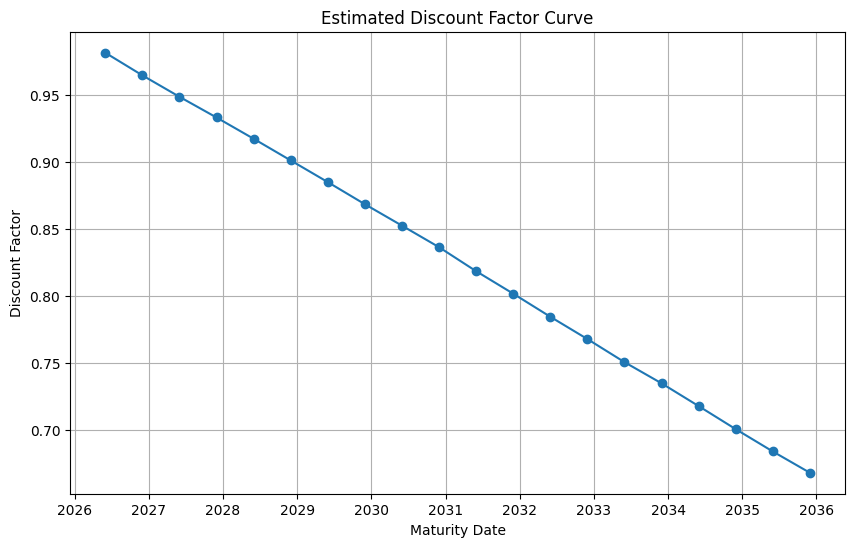

In [82]:
discount_factors = pd.DataFrame(data=z, index=date_index, columns=['Discount Factor'])
figure = plt.figure(figsize=(10,6))
plt.plot(discount_factors.index, discount_factors['Discount Factor'], marker='o')
plt.title('Estimated Discount Factor Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Factor')
plt.grid()
plt.show()

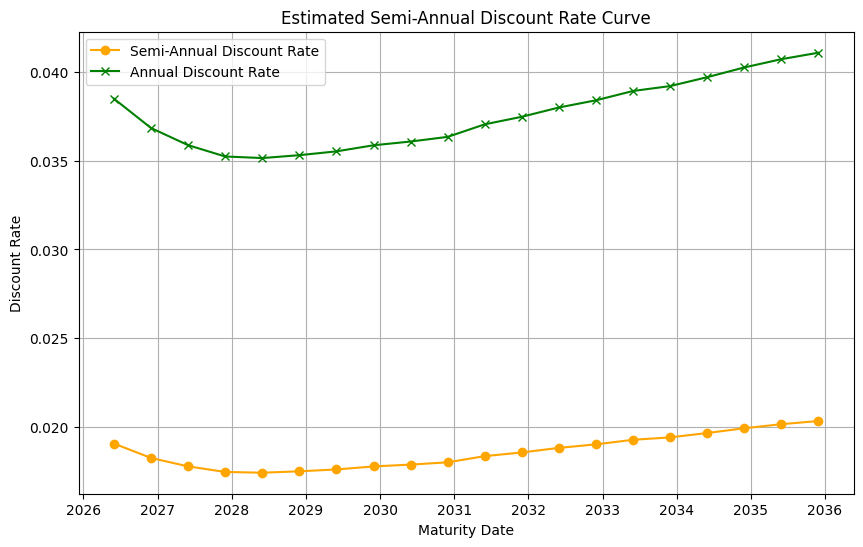

In [85]:
annual_discount_rates = (1/discount_factors['Discount Factor'])**(1/( (date_index - pd.Timestamp("2025-11-30")).days / 365 )) - 1
semi_annual_discount_rates = (1 + annual_discount_rates)**(1/2) - 1
plt.figure(figsize=(10,6))
plt.plot(semi_annual_discount_rates.index, semi_annual_discount_rates, marker='o', color='orange')
plt.plot(annual_discount_rates.index, annual_discount_rates, marker='x', color='green')
plt.title('Estimated Semi-Annual Discount Rate Curve')
plt.xlabel('Maturity Date')
plt.ylabel('Discount Rate')
plt.legend(['Semi-Annual Discount Rate', 'Annual Discount Rate'])
plt.grid()
plt.show()